In [1]:
# Importing Libraries
import tensorflow as tf 
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt 


In [2]:
# Paths
train_dir = "Dataset/training_set"
validation_dir = "Dataset/test_set"


In [3]:
import os

print(os.path.exists(train_dir))
print(os.path.exists(validation_dir))

True
True


In [4]:
# Define ImageDataGenerators for data augmentation and rescaling
train_datagen = ImageDataGenerator(
    rescale=1./255,             # Rescale pixel values (0-255) to (0-1)
    rotation_range=40,          # Randomly rotate image
    width_shift_range=0.2,      # Randomly shift image horizontally
    height_shift_range =0.2,    # Randomly shift image vertically
    shear_range =0.2,           # Randomly shear images
    zoom_range=0.2,             # Randomly zoom in on images
    horizontal_flip =True,      # Fill pixels that may have been lost after transformation
    fill_mode ='nearest'
)


In [5]:
# For the validation data, we just rescale ( no data augmentation)
validation_datagen = ImageDataGenerator(rescale=1./255)

In [6]:
# Load traininng and validation data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),      # Resize all images to 150 x 150
    batch_size = 32,
    class_mode='binary'         # Binary classification (Dog or cat)
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(150,150),
    batch_size =32,
    class_mode = 'binary'
)

Found 8005 images belonging to 1 classes.
Found 2023 images belonging to 1 classes.


In [7]:
# Define the CNN model
model= models.Sequential()

# First convolutional layer
model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)))
model.add(layers.MaxPool2D((2,2)))

# Second Convolutional layer 
model.add(layers.Conv2D(64,(3,3), activation='relu',))
model.add(layers.MaxPooling2D((2,2)))

# Third Convolutional layer 
model.add(layers.Conv2D(128,(3,3), activation='relu',))
model.add(layers.MaxPooling2D((2,2)))

# Fourth Convolutional layer 
model.add(layers.Conv2D(128,(3,3), activation='relu',))
model.add(layers.MaxPooling2D((2,2)))

C:\Users\Dell\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# Flatten the output from the convulational layers and add fully connected layers
model.add(layers.Flatten())
model.add(layers.Dense(512,activation='relu'))
model.add(layers.Dense(1,activation='sigmoid')) # Output layer for binary classification

In [9]:
# compile the model
model.compile(optimizer ='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [10]:
#print a summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
pip install scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# train the model
history=model.fit(
    train_generator,
    steps_per_epoch =100,       # number of batches per epochs
    epochs=3,                  # number of epochs to train
    validation_data=validation_generator,
    validation_steps=50         # Number of bathces for validation
)

Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/3
 51/100 ━━━━━━━━━━━━━━━━━━━━ 38s 780ms/step - accuracy: 1.0000 - loss: 0.0000e+00

C:\Users\Dell\AppData\Roaming\Python\Python310\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 50s 502ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00


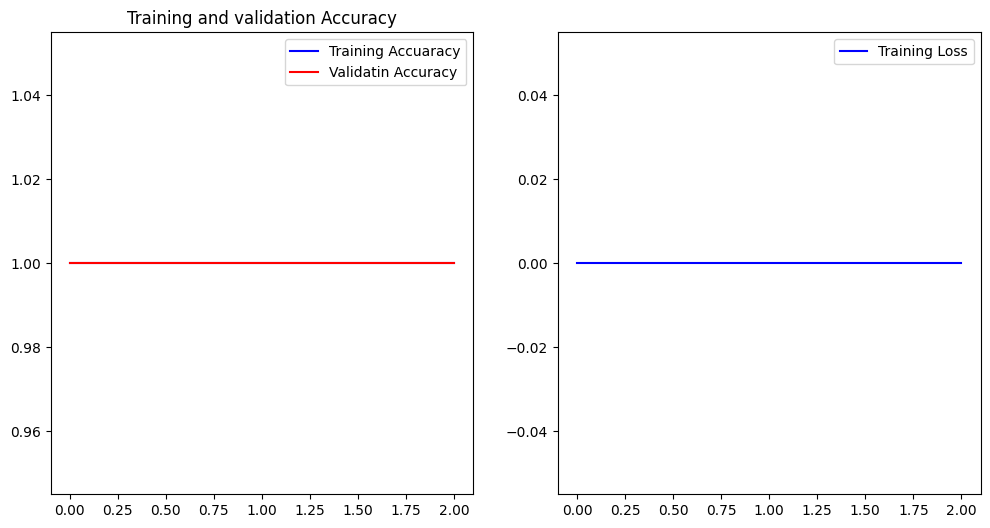

In [16]:
# Plot training and validation accuracy and loss
acc = history.history['accuracy']
val_acc =history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs =range(len(acc))

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(epochs,acc,'b', label ='Training Accuaracy')
plt.plot(epochs,val_acc,'r', label='Validatin Accuracy')
plt.title('Training and validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs,loss,'b',label='Training Loss')
plt.legend()
plt.show()

In [17]:
# Test the model with a new image
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_image(model, img_path):
    img = image.load_img(img_path, target_size=(150, 150))  # Load the image
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array /= 255.0  # Normalize the image (rescale pixel values to [0, 1])
    
    prediction = model.predict(img_array)  # Make the prediction
    
    if prediction[0] > 0.5:
        print(f"The image is predicted to be a Dog with a confidence of {prediction[0][0]:.2f}")
    else:
        print(f"The image is predicted to be a Cat with a confidence of {1 - prediction[0][0]:.2f}")

# Example: Test the classifier with a new image
predict_image(model, 'test_image.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
The image is predicted to be a Cat with a confidence of 1.00
